# FastAPI and Streamlit Lab on Google Colab

Let us setup the FastAPI and Streamlit Lab on Google Colab

The following steps are performed:    
1. Clone the MLOPS streamlit-labs branch to test error.
2. Setup virtual environment and install the packages from requirements.txt
3. Show before and after installing packages from requirements.txt
4. Since, Google Colab runs on a private server, we need to setup proxy to access the server from a public url. This amazing functionality is provided by localtunnel nodeJS package.
5. Run Streamlit application and connect via a public URL that you can share with your friends.
6. Run Fastapi and internally Streamlit will connect to the API.

### Clone the repository

In [1]:
!git clone https://github.com/raminmohammadi/MLOps.git

Cloning into 'MLOps'...
remote: Enumerating objects: 5234, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 5234 (delta 32), reused 22 (delta 22), pack-reused 5188 (from 2)
Receiving objects: 100% (5234/5234), 328.83 MiB | 20.20 MiB/s, done.
Resolving deltas: 100% (2560/2560), done.
Updating files: 100% (613/613), done.


### Setup virtual environment

In [19]:
!apt install python3.12-venv
# We call the virtual environment DevelopersVirtualEnvironment
!python3 -m venv DevelopersVirtualEnvironment

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  python3.12-venv
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 1,796 kB of archives.
After this operation, 1,871 kB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 python3.12-venv amd64 3.12.12-1+jammy1 [1,796 kB]
Fetched 1,796 kB in 8s (233 kB/s)
Selecting previously unselected package python3.12-venv.
(Reading database ... 121718 files and directories currently installed.)
Preparing to unpack .../python3.12-venv_3.12.12-1+jammy1_amd64.deb ...
Unpacking python3.12-venv (3.12.12-1+jammy1) ...
Setting up python3.12-venv (3.12.12-1+jammy1) ...


### Before installing packages from requirements.txt
The bare minimum packages when virtual environment is first created

In [20]:
!source ./DevelopersVirtualEnvironment/bin/activate && pip list

Package Version
------- -------
pip     25.0.1


### Installing packages from requirements.txt

Google Colab does not maintain the activation of virtual environments, which can be considered a limitation when utilizing python-venv within the platform. However, this challenge is overcome by activating the environment whenever it is required. Alternatively, another approach involves employing conda to establish virtual environments.

In [24]:
!pip install -r /content/MLOps/Labs/API_Labs/Streamlit_Labs/requirements.txt

  Using cached scikit_learn-1.5.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached fastapi-0.111.1-py3-none-any.whl.metadata (26 kB)
  Using cached streamlit-1.37.0-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached starlette-0.37.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached fastapi_cli-0.0.16-py3-none-any.whl.metadata (6.4 kB)
  Using cached email_validator-2.3.0-py3-none-any.whl.metadata (26 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached watchdog-4.0.2-py3-none-manylinux2014_x86_64.whl.metadata (38 kB)
  Using cached ujson-5.11.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (9.4 kB)
  Using cached pydantic_extra_types-2.10.6-py3-none-any.whl.metadata (4.0 kB)
  Using cached dnspython-2.8.0-py3-none-any.whl.metadata (5.7 kB)

### List the packages after installing from requirements.txt

In [25]:
!pip list

Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
absolufy-imports                         0.3.1
accelerate                               1.11.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.1
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.11.0
anywidget                                0.9.19
argon2-cffi                        

### Install localtunnel

In [1]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

### Run the Streamlit application

In this step we run the Streamlit application from the lab.

1. First, we activate the environment.   
2. Run the streamlit command to start the server
3. Pipe the stdout to logs.txt to debug and track server logs

In [5]:
#!source /content/DevelopersVirtualEnvironment/bin/activate ;
!streamlit run /content/MLOps/Labs/API_Labs/Streamlit_Labs/src/Dashboard.py &>/content/logs.txt &

### Setup Localtunnel

In this step we run localtunnel inside a process since it is resouce intensive. Note, we capture the output into `localtunnel_output.txt`, which captures the public URL once it is available.

User has to click on the public URL and paste the password to access the Streamlit application.

In [6]:
import subprocess
import threading
def run_streamlit_tunnel():
  process = subprocess.Popen(['npx', 'localtunnel', '--port', '8501'], stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
  with open('localtunnel_output.txt', 'w') as output_file:
    for line in process.stdout:
        # Write the server URL to output file
        if 'your url is:' in line:
            output_file.write(line)
            break
  # Keep the subprocess running in background
  process.wait()
  # Check if there was any error
  if process.returncode != 0:
      error_output = process.stderr.read()
      print(f"Error: {error_output}")
# Run this inside a thread so that Google Colab doesn't get stuck running this cell
# This is a good example of using Threads
# over subprocess as threads are typically
# employed for managing tasks with low resource requirements.
localtunnel_thread = threading.Thread(target=run_streamlit_tunnel)
localtunnel_thread.start()

In [7]:
from IPython.display import HTML
import time
# The JS for Google Colab takes a few seconds
# to update. If this code errors out wait a little
# and re-run.
time.sleep(10)
# Print the public URL for streamlit application
with open('localtunnel_output.txt', 'r') as file:
  lines = file.readlines()
  print(f"Access the application at: {lines[0].replace('your url is: ','')}")
# Print Password
with open('logs.txt', 'r') as file:
  lines = file.readlines()

for line in lines:
    if 'External URL' in line:
        external_url = line.split(': ')[1].strip()
        print(f'Password: {external_url[7:-5]}')
        break
# Give user the ability to copy password into clipboard
html_text = f'''<h3>Password:</h3><input type="text" value="{external_url[7:-5]}" id="clipborad-text">
                <button onclick="copyToClipboard()">Copy to clipboard</button>
                <script>
                function copyToClipboard() {{
                    var copyText = document.getElementById("clipborad-text");
                    copyText.select();
                    navigator.clipboard.writeText(copyText.value);
                }}
                </script>'''
display(HTML(html_text))

Access the application at: https://tricky-ties-shake.loca.lt

Password: 34.81.61.133


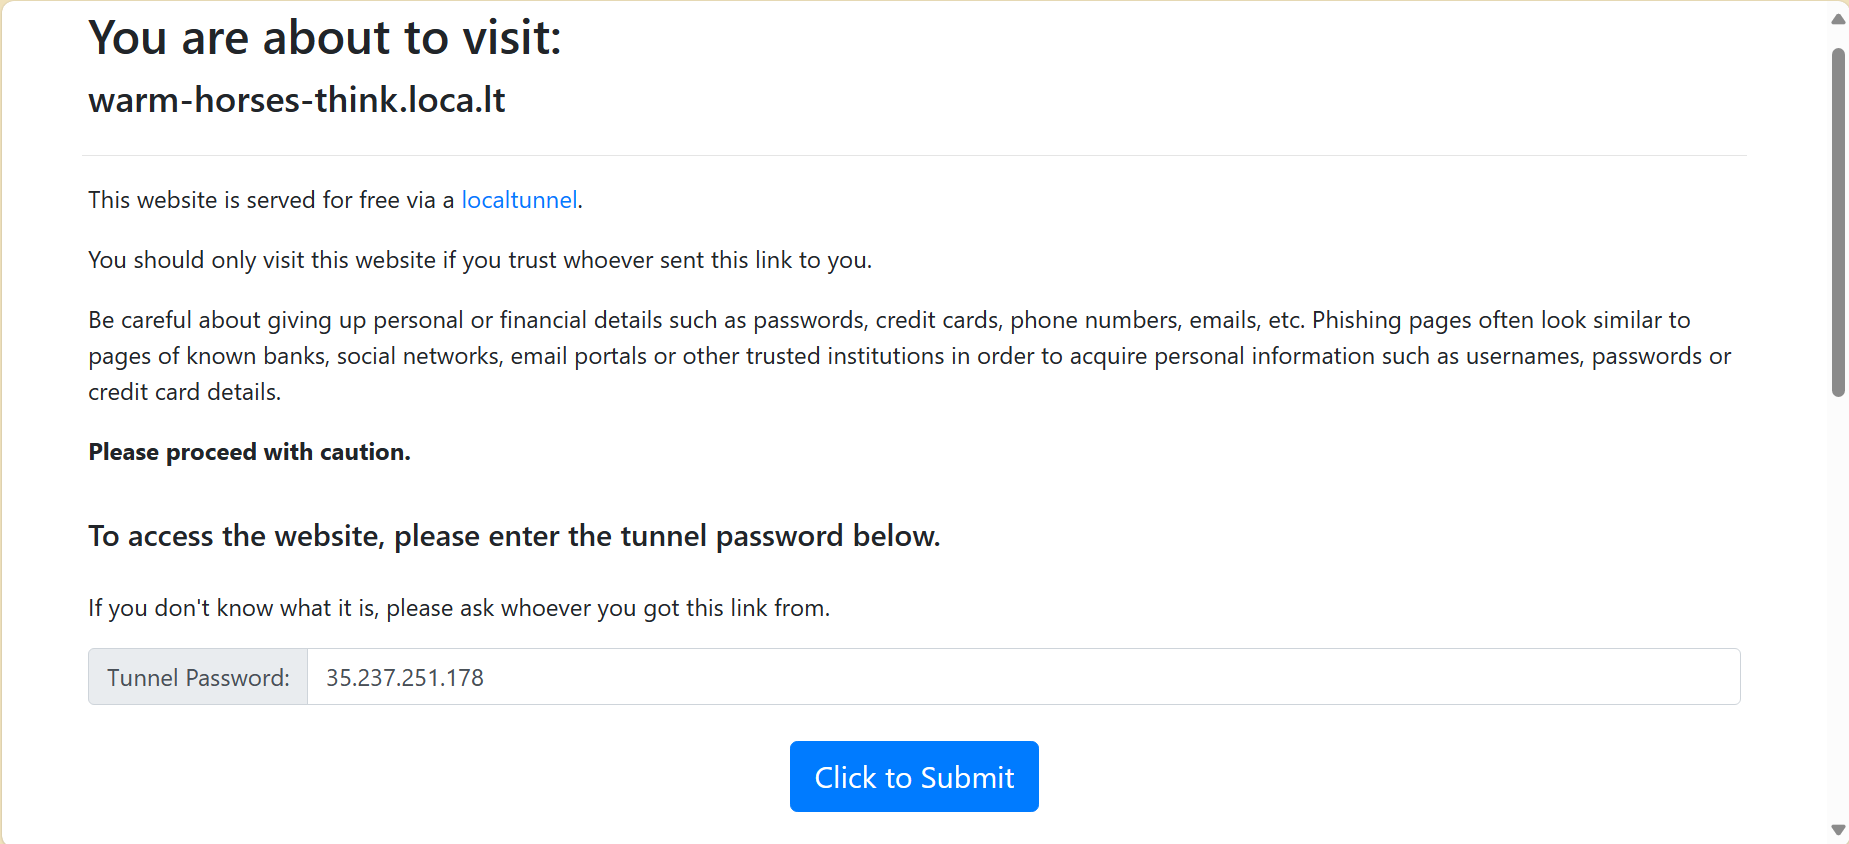

### BELOW IS THE OUTPUT -- Backend is currently offline..

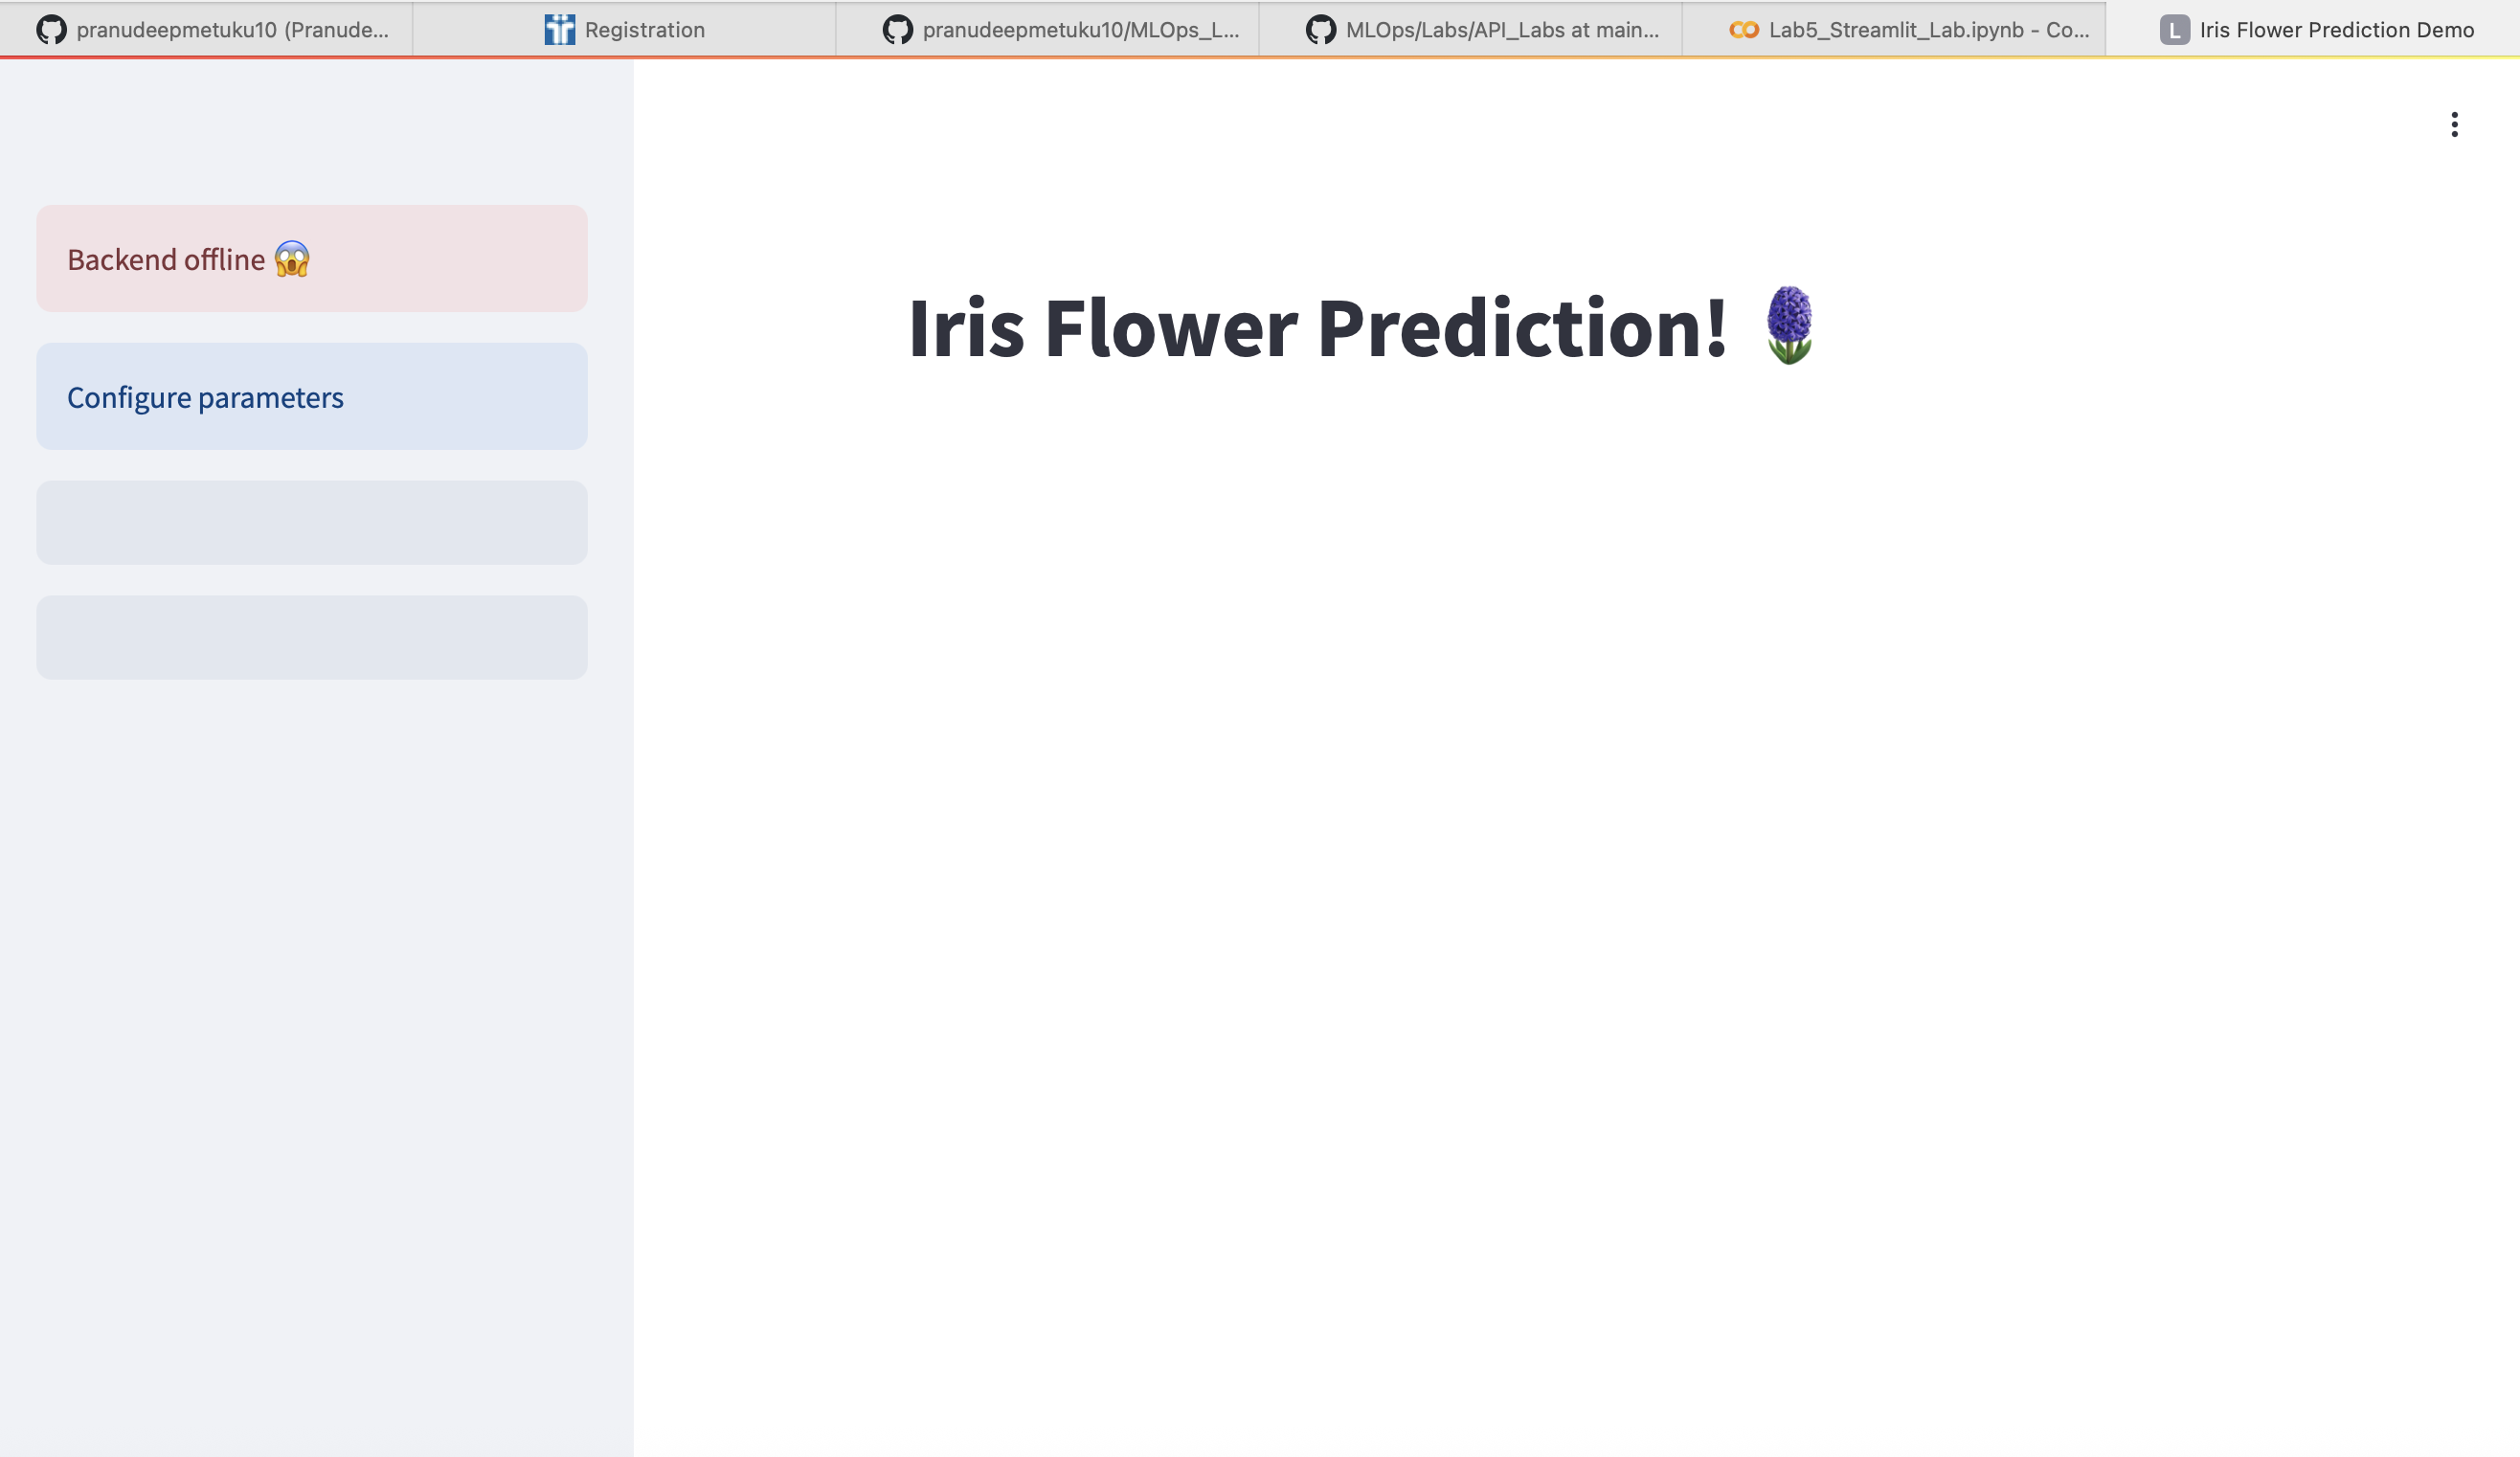

### Running FastAPI server

If you access the Streamlit server before running this step, you will see the backend as offline as shown in the image below.

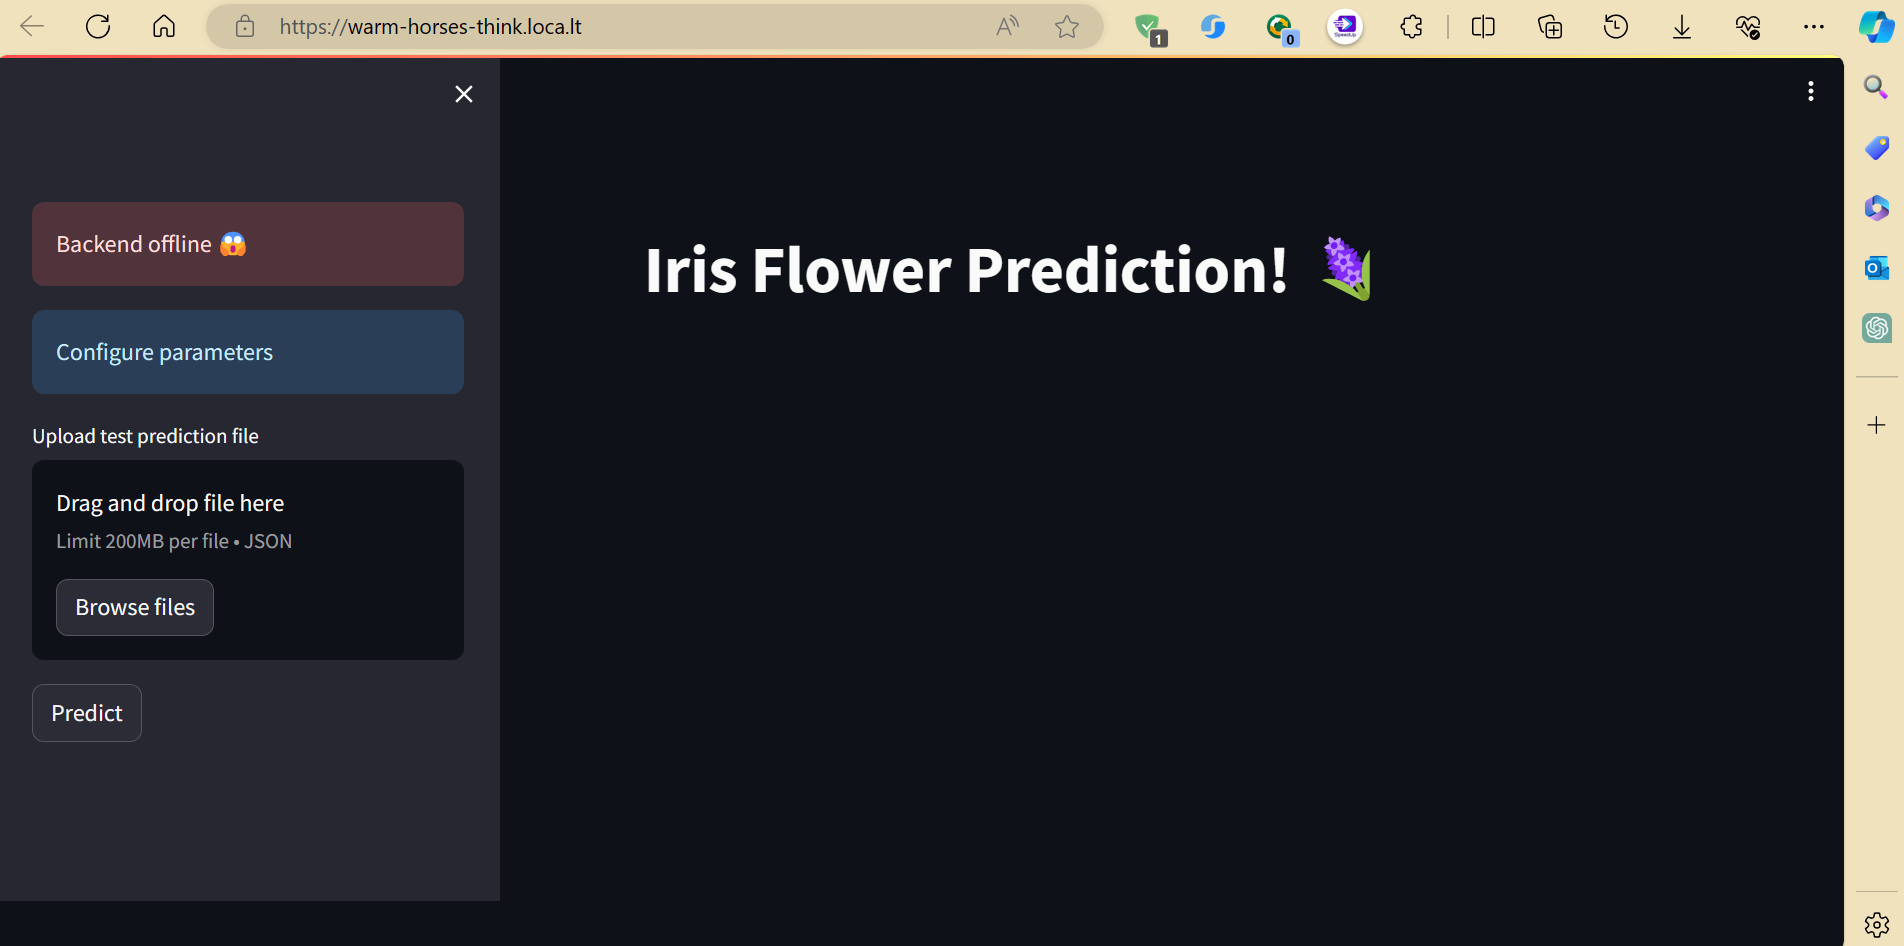

## Let's start the backend server.

### Change directory to point to the backend server source files location

In [13]:
%cd /content/MLOps/Labs/API_Labs/FastAPI_Labs/src/.

/content/MLOps/Labs/API_Labs/FastAPI_Labs/src


### Run the train.py

This step will create the iris_pickle.pkl model file which will be used for the Iris flower prediction.

In [14]:
!python train.py

### Start the server

Steps to start the server

1. Activate virtual environment
2. Start the server using uvicorn command
3. Pipe all server output to logs1.txt

In [15]:
!uvicorn main:app --reload &>/content/logs1.txt &

Finally, refresh the Streamlit server.

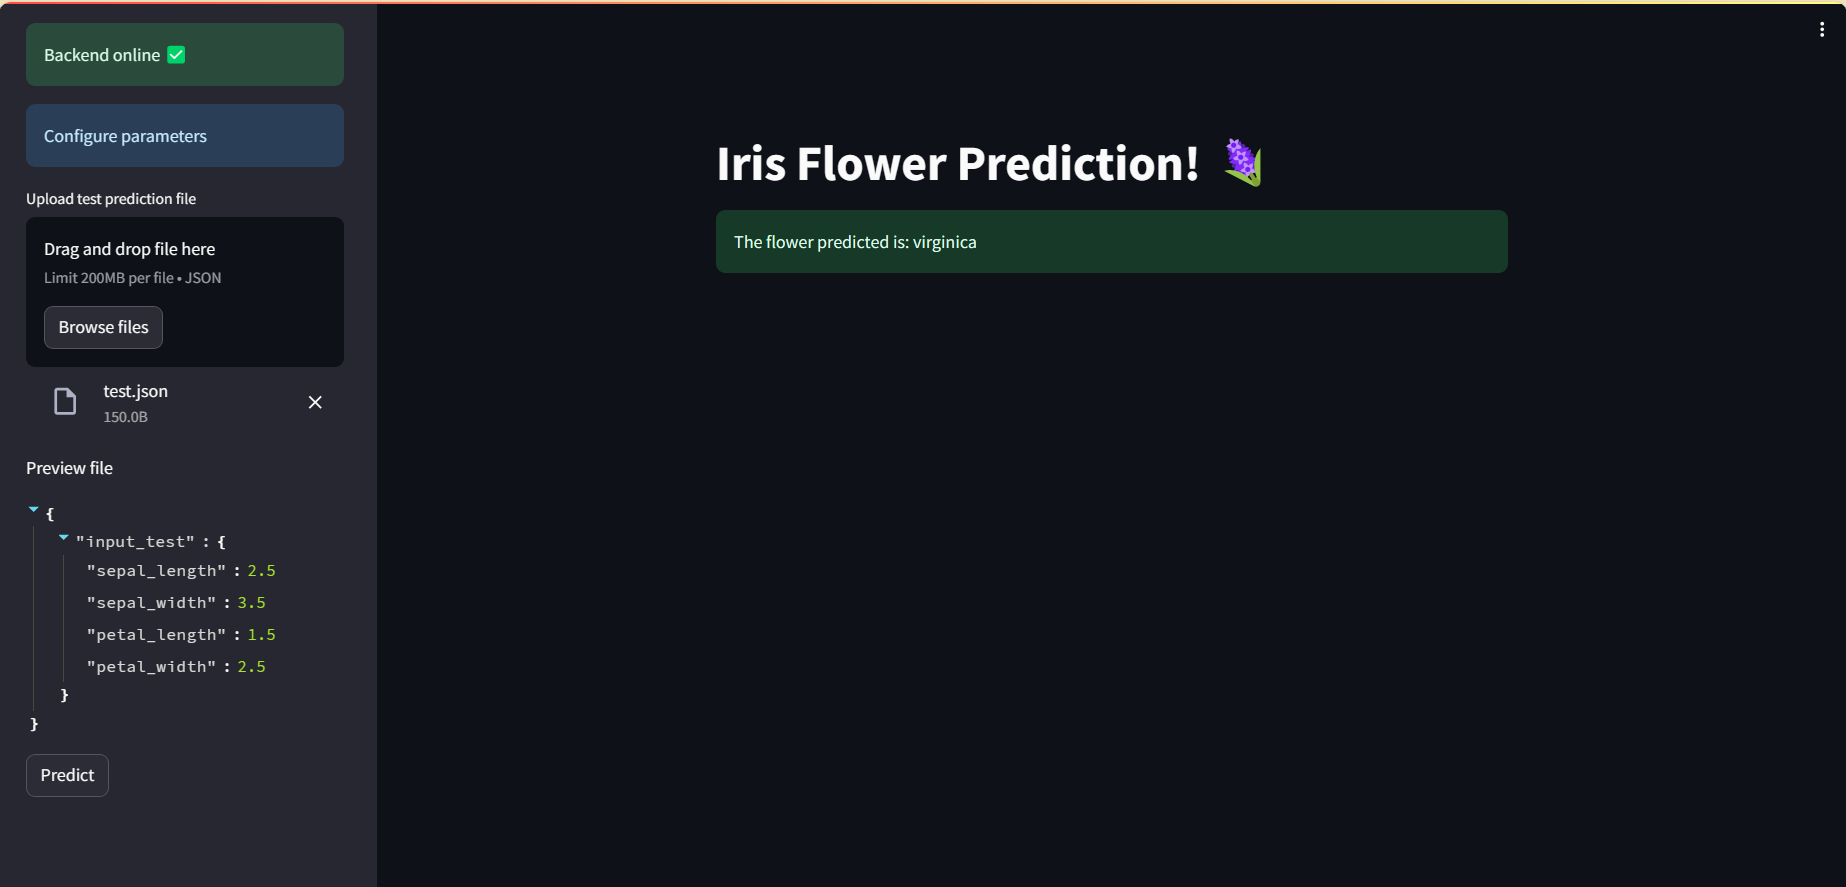

https://tricky-ties-shake.loca.lt/

pass: 34.81.61.133

log1.txt Output -

---
```
INFO:     Will watch for changes in these directories: ['/content/MLOps/Labs/API_Labs/FastAPI_Labs/src']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [8460] using WatchFiles
INFO:     Started server process [8462]
INFO:     Waiting for application startup.
INFO:     Application startup complete.

```

# Result of this Lab 5 : "Our API is working with expected Behavior!"

### Conclusion

We now have the ability to run our demo's on a free Google Colab notebook instance and share the application with the world!